## XMAC02 - Lista Exercícios

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats import proportion, weightstats

### Questão 1
Utilizando o dataset "IMC_paises.csv", considere a seguinte afirmação: "O IMC de homens e mulheres em nível global é equivalente". Para verificar se isso é verdade, realize um teste de hipótese com o IMC Nacional (National) e utilize dados do ano 2017. Informe o teste escolhido e o resultado obtido. Interprete o resultado e informe se a afirmação é verdadeira de acordo com o teste realizado. Em seguida, plote dois boxplots que exibam os dados de IMC de homens e mulheres e confronte com o resultado do teste de hipótese. Finalmente discuta se o resultado do teste está de acordo com a informação exibida nos boxplots. Realize o teste de hipótese com nível de confiança de 95%.

In [2]:
# H0 = IMC_homens == IMC_mulheres
# HA = IMC_Homens <> IMC_Mulheres

df = pd.read_csv('IMC_paises.csv')

df_men = df[(df['Sex']=='Men') & (df['Region']=='National') & (df['Year']==2017)]['IMC']

df_women = df[(df['Sex']=='Women') & (df['Region']=='National') & (df['Year']==2017)]['IMC']

weightstats.ztest(df_men, df_women)

(np.float64(-2.9968530694244127), np.float64(0.0027278215388439266))

O pValue obtido (0.0027) é menor que alpha. Assim, o teste rejeita a hipótese nula, então a afirmação que homens e mulheres têm o mesmo IMC médio não é verdadeira.

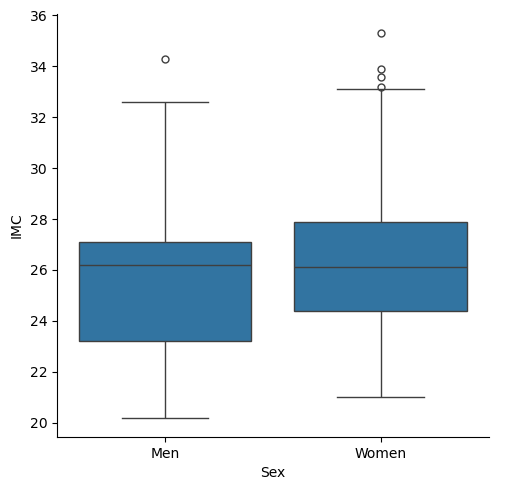

In [3]:
df_test = df[(df['Region']=='National') & (df['Year']==2017)]
sns.catplot(data=df_test, x='Sex', y='IMC', kind='box')

### Questão 2
Dataset questão 4: IMC_paises.csv. \
Considere a seguinte afirmação: "Os homens estão mais magros em 2017 do que estavam em 1985". Para realizar um teste de hipótese capaz de confirmar ou refutar essa afirmação, você deverá gerar dois conjuntos de dados (dois dataframes) contendo 20 registros cada. O primeiro dataframe deverá conter o IMC de homens da região nacional (National)e do ano de 1985, e o segundo dataframe deverá conter esses mesmos dados do ano de 2017. Note que os dados da posição n de cada conjunto devem ser do mesmo país. Para tanto, você pode selecionar os 20 primeiros registros de cada dataframe criado. Com os dados filtrados nos dataframes df1 e df2, realize o teste de hipótese e analise o resultado. Você deve informar a hipótese nula, a hipótese alternativa, o teste escolhido, o resultado obtido e, finalmente, analisar o resultado dizendo se a afirmação deve ser confirmada ou refutada.

In [4]:
# H0: IMC_Homens_2017 >= IMC_Homens_1985
# HA: IMC_Homens_2017 < IMC_Homens_1985

df1 = df[(df['Sex']=='Men') & (df['Region']=='National') & (df['Year']==1985)]['IMC']
df2 = df[(df['Sex']=='Men') & (df['Region']=='National') & (df['Year']==2017)]['IMC']
df1 = df1.head(20)
df2 = df2.head(20)
stats.ttest_rel(df1, df2, alternative='greater')

TtestResult(statistic=np.float64(-17.18762468917212), pvalue=np.float64(0.9999999999997546), df=np.int64(19))

Conclusão: \
pvalue > 0.05 => falha em rejeitar a hipótese nula, os homens não estão mais magros em 2017.

### Questão 3
João e Pedro são dois treinadores de fitness que querem comparar seus taxa de satisfação do cliente. João escolheu uma amostra aleatória de 85 clientes e Pedro escolheu uma amostra aleatória de 72 clientes. João descobriu que 89% de seus
clientes ficaram satisfeitos e Pedro descobriu que 91% de seus clientes estavam satisfeitos. Usando um nível de confiança de 95%, informe se existe diferença na satisfação dos clientes de João e Pedro.

H0: p1 - p2 = 0 \
Ha: p1 - p2 ≠ 0

In [5]:
proportion.test_proportions_2indep(75.65, 85, 65.52, 72, method='score')

<class 'statsmodels.stats.base.HolderTuple'>
statistic = np.float64(-0.41338654892272453)
pvalue = np.float64(0.6793234280733379)
compare = 'diff'
method = 'score'
variance = np.float64(0.002340708375230431)
alternative = 'two-sided'
prop1_null = np.float64(0.8991719745222931)
prop2_null = np.float64(0.8991719745222931)
tuple = (np.float64(-0.41338654892272453), np.float64(0.6793234280733379))
diff = np.float64(-0.019999999999999907)
ratio = np.float64(0.9780219780219781)
odds_ratio = np.float64(0.8001998001998011)
value = 0

Conclusão: temos pvalue = 0,67 > 0,05. Assim, falhamos em rejeitar a hipótese nula. Portanto, as proporções são iguais e concluímos que a taxa de satisfação dos clientes dos dois treinadores é igual.

### Questão 4
São considerados obesos indivíduos com bmi >= 30. Utilizando o dataset 'insurance' realize um teste de hipótese que verique se indivíduos obesos gastam mais com o seguro saúde quando comparados com indivíduos não obesos. Realize seu teste com um nível de confiança de 95%.

H0: μ(gasto_obeso) <= μ(gasto_nao_obeso) \
Ha: μ(gasto_obeso) > μ(gasto_nao_obeso)

In [6]:
df = pd.read_csv('insurance.csv')
obeso = df[df['bmi']>=30]
nao_obeso = df[df['bmi']<30]
obeso

,age,sex,bmi,children,smoker,region,charges
1,18,male,33.77,1,no,southeast,1725.55230
2,28,male,33.00,3,no,southeast,4449.46200
6,46,female,33.44,1,no,southeast,8240.58960
12,23,male,34.40,0,no,southwest,1826.84300
13,56,female,39.82,0,no,southeast,11090.71780
...,...,...,...,...,...,...,...
1331,23,female,33.40,0,no,southwest,10795.93733
1332,52,female,44.70,3,no,southwest,11411.68500
1333,50,male,30.97,3,no,northwest,10600.54830
1334,18,female,31.92,0,no,northeast,2205.98080


In [7]:
stats.ttest_ind(obeso['charges'], nao_obeso['charges'], equal_var=True)

TtestResult(statistic=np.float64(7.442815495893551), pvalue=np.float64(1.7585561273951227e-13), df=np.float64(1336.0))

Conclusão: \
Como temos um pvalue muito pequeno, rejeitamos a hipótese nula. Portanto, há fortes indícios que indivíduos obesos gastam mais com seguro saúde.

### Questão 5
Teste a afirmação de que, em 2006, o peso médio dos homens nos EUA não era significativamente diferente do peso médio das mulheres. Pesquisa anterior mostrou que os desvios padrão da população eram de 10,25 libras para homens e 8,58 libras para mulheres. Uma amostra aleatória de 1.500 homens tem peso médio de 193,5 libras e uma amostra aleatória de 1.500 mulheres tem um peso médio de 185,3 libras. Supondo que as variâncias populacionais sejam desiguais, realize um teste de hipótese com confiança de 95% para testar essa afirmação.

In [8]:
dp1 = 10.25
dp2 = 8.58
n1 = 1500
n2 = 1500
x1 = 193.5
x2 = 185.3
z_calc = (x1 - x2) / np.sqrt((dp1*dp1)/n1 +(dp2*dp2)/n2)
z_calc

np.float64(23.758709468283254)

Conclusão: \
Para alpha = 0,05 e duas caudas, temos z_crítico = 1,96. Como z_calc é muito maior que z_crítico, rejeitamos a hipótese nula e concluímos que o peso médio de homens e mulheres é diferente.